In [ ]:
# Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

In [4]:
df = pd.read_csv('IRIS.csv')

In [5]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [7]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [8]:
df.duplicated().sum()

3

In [9]:
df.drop_duplicates()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [10]:
# Visualization

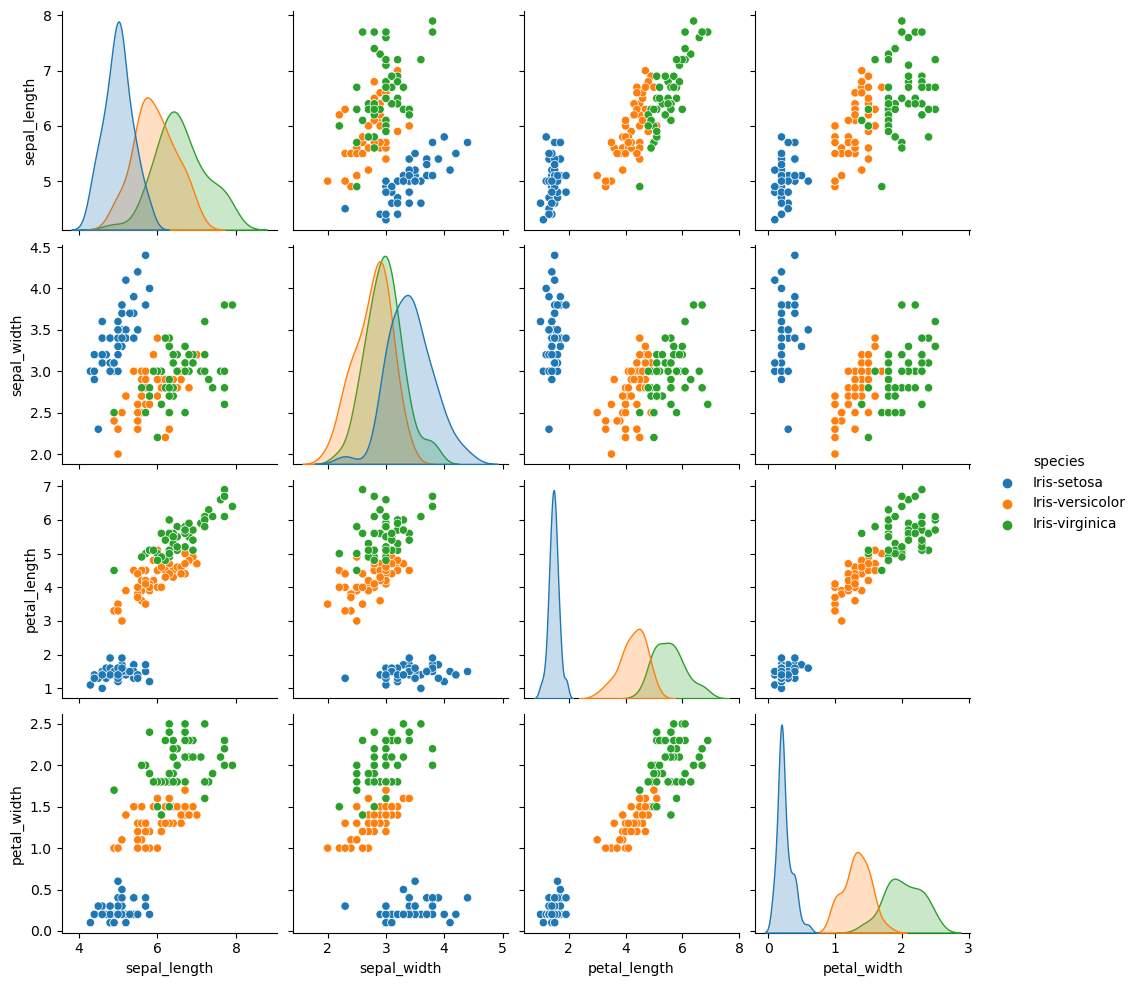

In [11]:
sns.pairplot(df, hue=df.columns[-1])
plt.show()

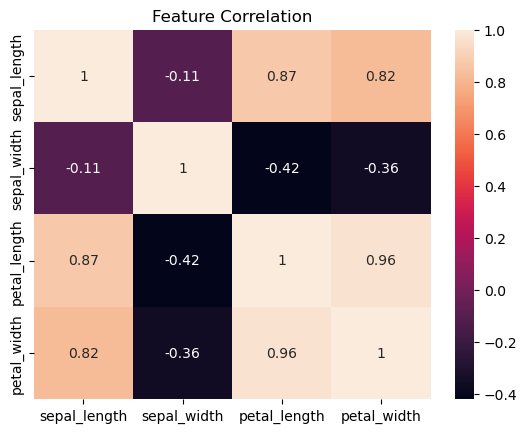

In [12]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation")
plt.show()

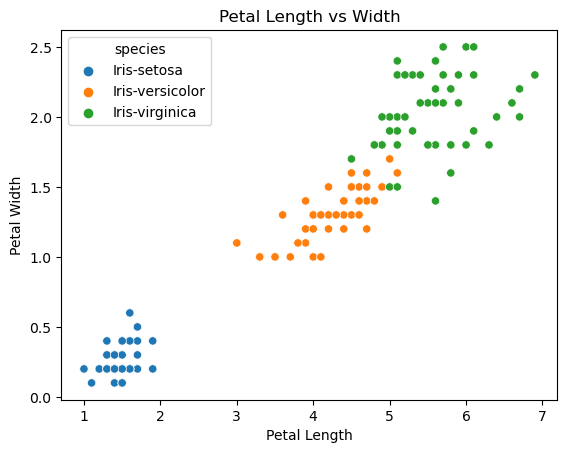

In [14]:
plt.figure()
sns.scatterplot(
    x=df.iloc[:,2],
    y=df.iloc[:,3],
    hue=df.iloc[:,-1]
)
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Petal Length vs Width")
plt.show()

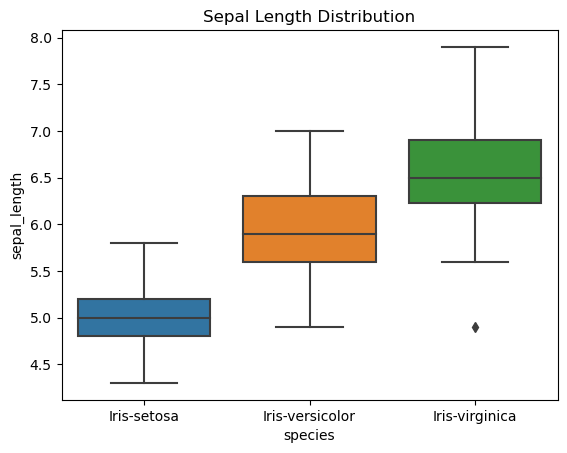

In [15]:
plt.figure()
sns.boxplot(x=df.iloc[:,-1], y=df.iloc[:,0])
plt.title("Sepal Length Distribution")
plt.show()

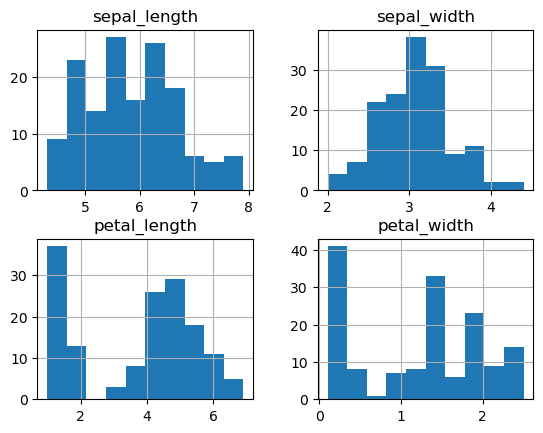

In [16]:
df.hist()
plt.show()

In [17]:
# Preparing data for model training

In [18]:
x = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [19]:
le = LabelEncoder()
y = le.fit_transform(y)

In [21]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [22]:
# Training the Model

In [23]:
model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [24]:
y_pred = model.predict(x_test)

In [25]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification_report:\n")
print(classification_report(y_test,y_pred))


Accuracy: 1.0

Classification_report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



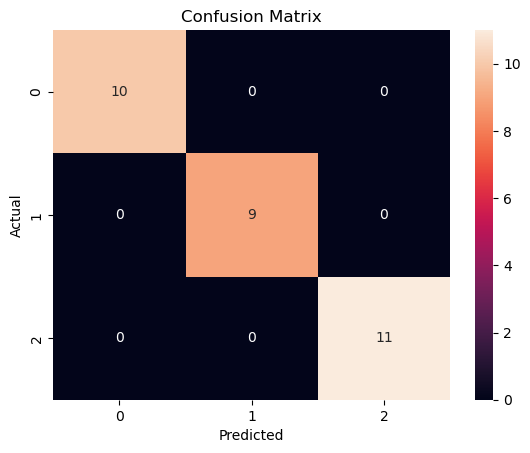

In [26]:
cm = confusion_matrix(y_test,y_pred)

plt.figure()
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()